# OMISH — gene biomarkers for weight-loss response

Reproducible record of every step. Each section explains what we do, why it applies to this cohort (n=89, p=13,519), the consequences, and the checkpoint decision. Code lives in `stepNN_*.py`; each section runs its script so the notebook and the scripts cannot diverge. Seeds are fixed. See `README.md` for the full plan and `DECISIONS.md` for the checkpoint log.

## Step 1 — Experiment design

**What we do.** Fix the rules of evidence before any model: positive class, cost of each error, primary metric, baselines, evaluation scheme.

**Why here.** With 13,519 genes and 89 samples, almost any method finds genes that separate the classes on the data it was fitted to. Deciding the rules first, and not changing them to fit the result, is the only defence.

**Decisions (see DECISIONS.md).**
- Positive class: Responders (54/89).
- Error costs: a spurious biomarker gene costs more than a missed one; selection stability outranks raw score.
- Primary metric: ROC-AUC under repeated stratified CV, with PR-AUC and confusion matrix alongside.
- Baselines: chance, and clinical-only (Age, Sex, COPD, Diabetes). A gene signature must beat clinical-only.
- Evaluation: no single hold-out split (an 18-sample test set gives an AUC interval about 0.47 wide). Repeated stratified k-fold with every supervised step nested inside folds.

**Consequences.** Unstable genes are reported as unstable, not as biomarkers. Expect a short candidate list. No claim of generalisation to other cohorts without external data.

In [1]:
%run step01_design.py

samples: 89   Responders: 54   Non_responders: 35
majority-class accuracy (chance baseline): 0.607
chance AUC: 0.500

Expected 95% CI width of an AUC estimate (true AUC 0.75):
  single 20% hold-out set (n=18): 0.47
  all samples via CV (n=89):      0.21

Clinical covariates vs label (potential confounders):
  Age    mean R=+0.09 NR=-0.15  t-test p=0.260  AUC=0.561
  Sex      rate R=0.44 NR=0.54  Fisher p=0.393  AUC=0.451
  COPD     rate R=0.41 NR=0.49  Fisher p=0.516  AUC=0.461
  Diabetes rate R=0.28 NR=0.26  Fisher p=1.000  AUC=0.510


## Step 2 — Exploratory data analysis

**What we do.** Look at the data before any model: per-sample expression distributions (normalisation), a sex-gene check against the Sex column (sample identity), PCA of all genes coloured by response and by each clinical covariate and by GEO series (batch), and an outlier scan. Everything here is unsupervised: the label is used only for colouring, never to change the data, so nothing leaks into later steps.

**Why here.** In a p >> n cohort the dominant sources of variance are usually technical (batch, array quality, sample swaps), not biology. If any of them align with the response label, a model will learn them and report them as biomarkers. PCA shows where the big variance is and whether it lines up with anything we know.

**How to read the PCA.** Each dot is one participant, placed by the two directions of largest expression variance. If Responders and Non-responders form separate clouds, the response signal is large and easy. If they overlap, the signal (if any) is small relative to other variance, and feature selection has to work harder. The same reading applies to Sex, COPD, Diabetes and batch: a covariate that separates on PC1 or PC2 is a confounder to control.

**Findings.**
- Arrays are on a common scale (per-sample medians 3.3–4.2); no re-normalisation needed.
- **Two GEO series are mixed: GSM1123xxx (63 samples) and GSM1616xxx (26 samples). They behave as two batches.** The GSM1616 samples spread along PC1 (SD 110 vs 24) and hardly at all along PC2 (SD 7 vs 39); the GSM1123 samples do the opposite. PC1 (28.5% of all variance) is therefore mostly batch, not biology.
- The sex-gene check confirms it: GSM1123 samples fall into clean female (high XIST) and male (high RPS4Y1) clusters and agree with the Sex column in 98% of cases. All 26 GSM1616 samples sit in a third, intermediate cluster where both genes are half-expressed. That pattern is not biological; it indicates a different platform, processing, or pooling for that series. The Sex column cannot be verified for those 26.
- One GSM1123 sample (GSM1123370) is labelled female but has a male expression profile: a probable sample or label swap.
- Batch is not associated with response (16/26 vs 38/63 responders), so it will not be learned as a proxy for the label. It will add noise and can hide real signal.
- No PC1–PC5 separates response, sex, COPD, diabetes or age. The response signal, if present, is small relative to the batch and other variance.

**Consequences.** Any gene ranking on the pooled 89 samples will be inflated by batch variance. Options for the checkpoint: (a) drop the 26 GSM1616 samples and work with 63 clean ones; (b) keep all 89 and correct for batch inside every CV fold (e.g. per-batch centring or a batch covariate in the model); (c) analyse per batch and require a gene to replicate in both. Sample GSM1123370 should be excluded or its label checked against GEO metadata.


**Update from GEO metadata (GSE66175, `GSE66175_samples.txt`).** All 89 samples are baseline arrays, one per participant, all from the intervention arm. The two GSM prefixes are two array batches of the same study, not different cohorts. Consequences: the question is "does baseline expression predict later response", which is the useful clinical framing; there are no repeated measures, so stratified CV over samples is valid; the batch correction stands. GSM1123370 is participant cv000777, baseline, labelled female, male expression profile, Responder.

In [2]:
%run step02_eda.py

per-sample median expression: min 3.31  max 4.17  (spread 0.85)
Sex==0: n=46  XIST mean=4.66  RPS4Y1 mean=4.09
Sex==1: n=43  XIST mean=1.71  RPS4Y1 mean=7.56
fraction agreeing with Sex column if 1=male: 0.89  (if 1=female: 0.11)
samples whose sex genes disagree with Sex column: ['GSM1123370', 'GSM1616283', 'GSM1616289', 'GSM1616295', 'GSM1616319', 'GSM1616325', 'GSM1616331', 'GSM1616343', 'GSM1616349', 'GSM1616377']
variance explained by PC1..PC5: 28.5%, 8.0%, 5.0%, 3.7%, 3.0%

PC vs variable (AUC for binary, |Spearman r| for Age); values near 0.5 / 0 mean no relation:
       Response       Sex      COPD  Diabetes       Age
PC1        0.56      0.54      0.58      0.58      0.02
PC2        0.59      0.50      0.60      0.60      0.12
PC3        0.61      0.50      0.53      0.57      0.03
PC4        0.53      0.55      0.60      0.51      0.14
PC5        0.57      0.57      0.51      0.61      0.00

GEO series prefix as batch: GSM1123=63  GSM1616=26
batch x response:
Responder   0   1


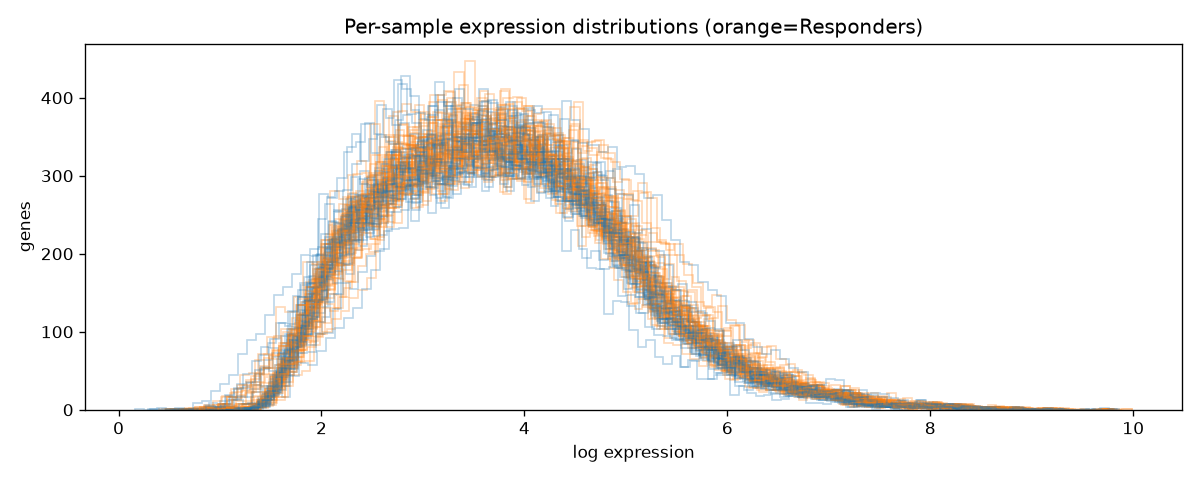

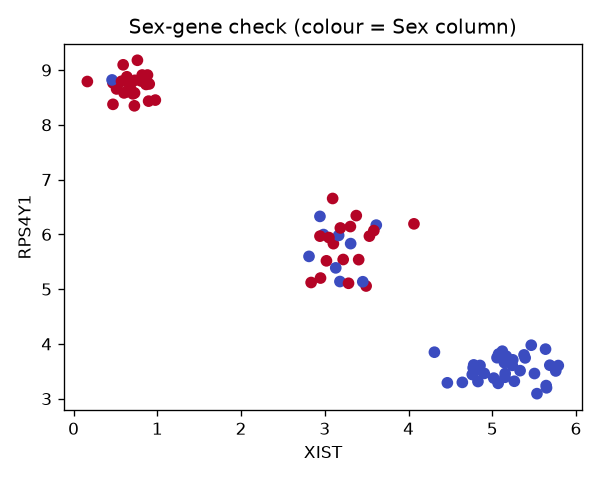

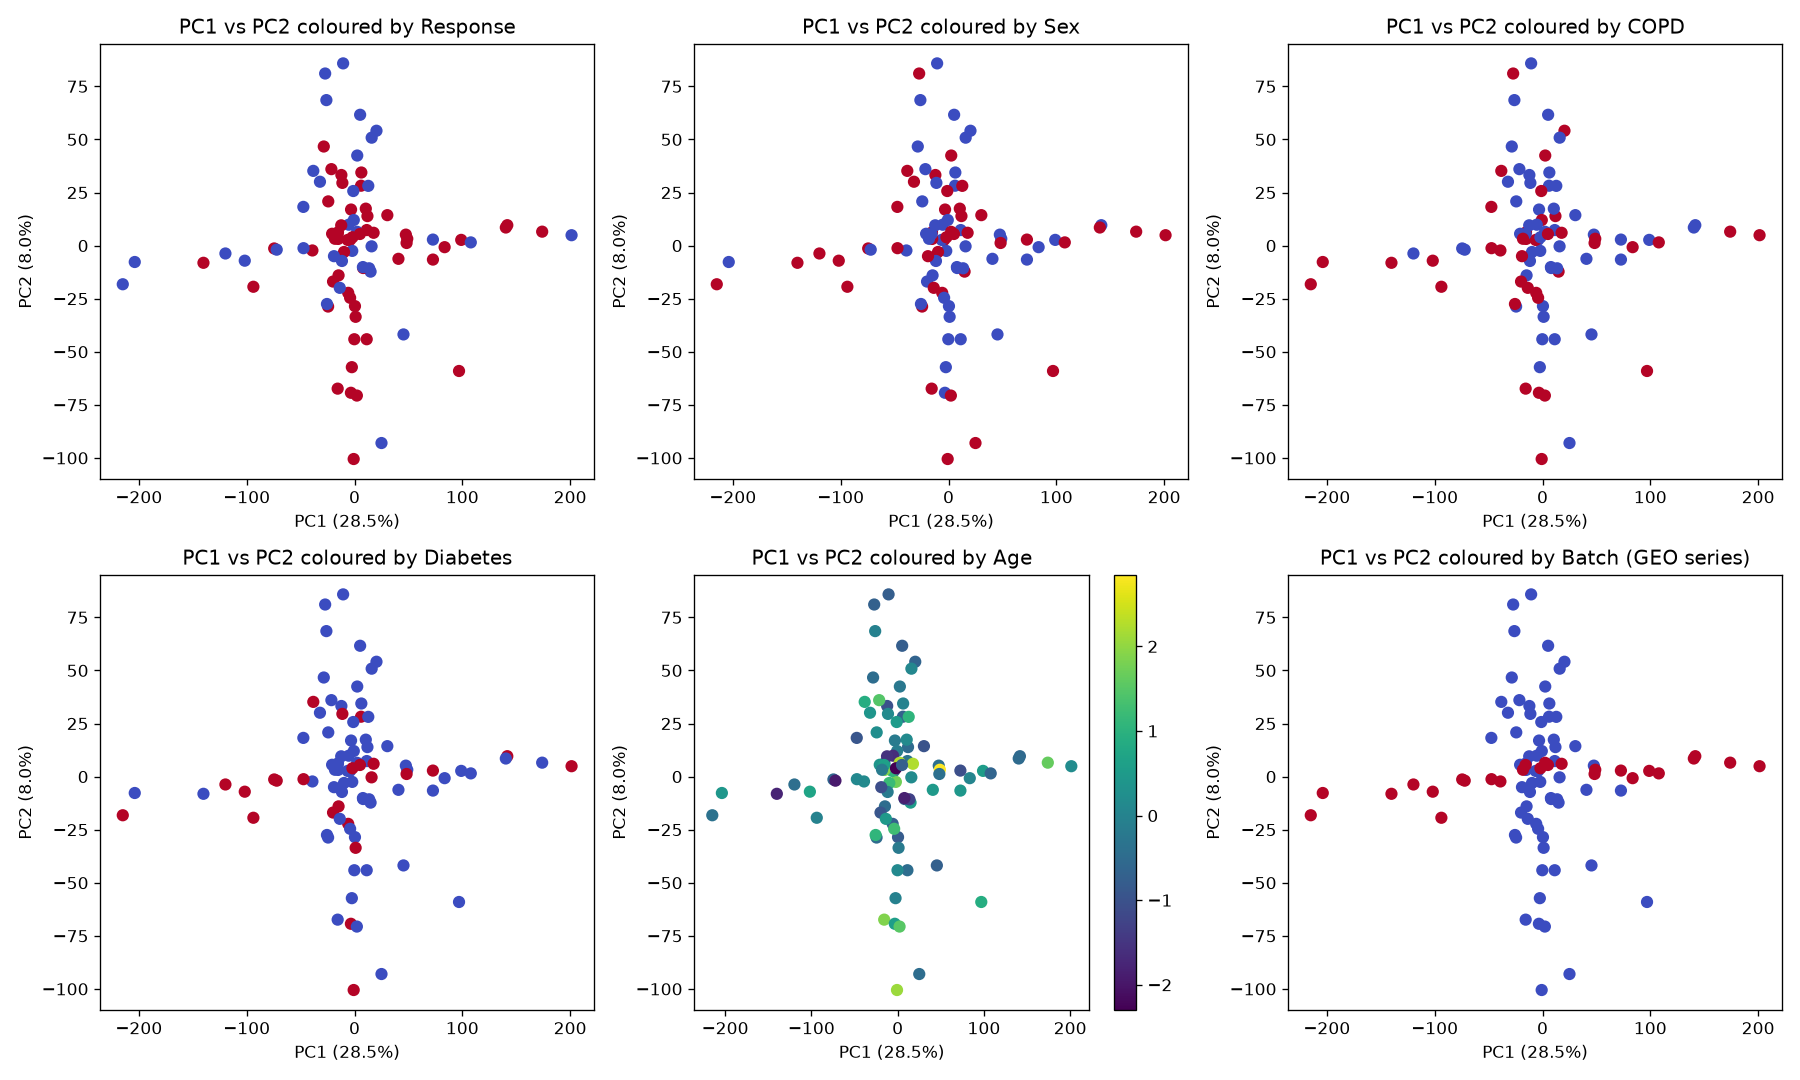

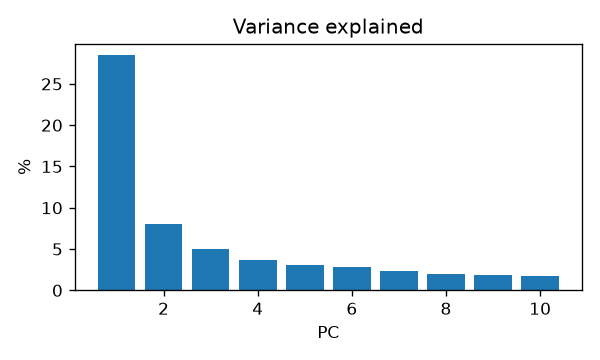

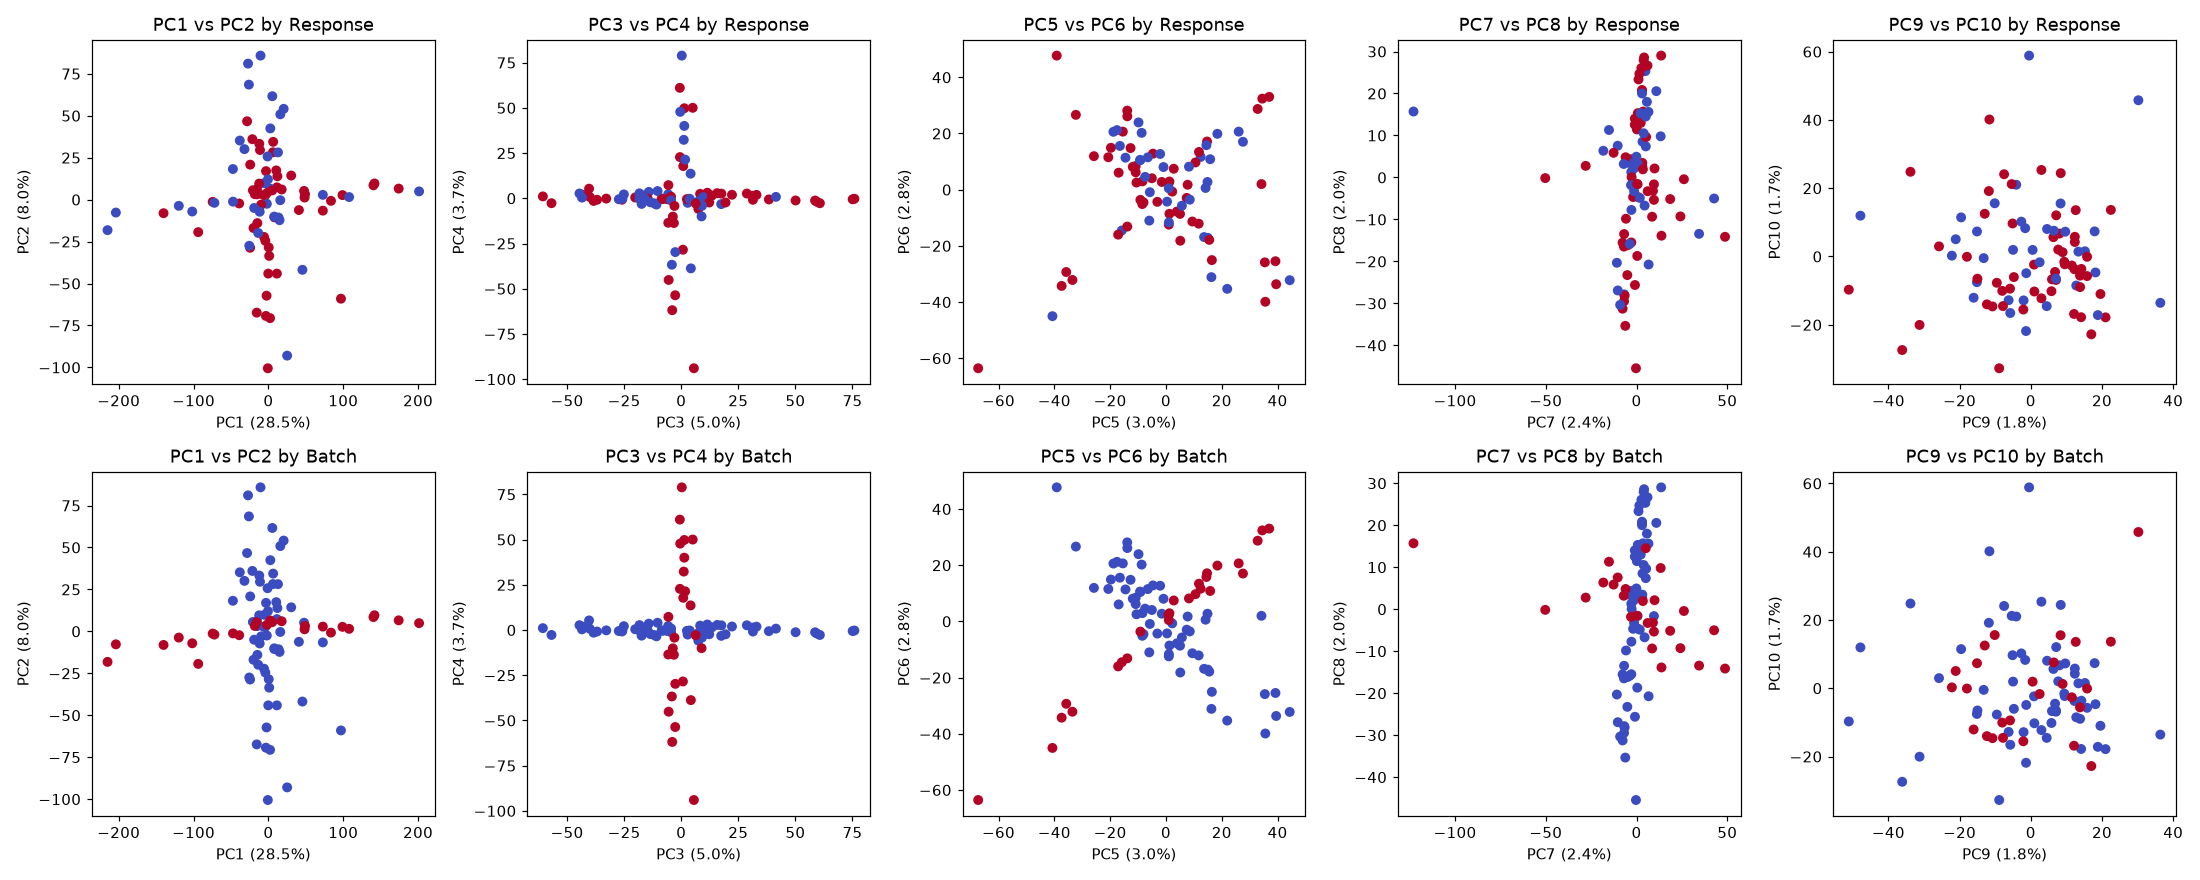

In [3]:
from IPython.display import Image, display
for f in ['results/step02_distributions.png','results/step02_sexcheck.png','results/step02_pca.png','results/step02_pca_variance.png','results/step02_pca_1to10.png']: display(Image(f))

## Step 3 — ComBat batch correction and WGCNA gene modules

**Decision from step 2.** Keep all 89 samples and correct the two array batches (earlier GSM1123, later GSM1616) with ComBat. GSM1123370 stays in, flagged as a probable sex swap.

**What ComBat does.** For every gene it estimates how much each batch shifts the level and how much it stretches the spread, then removes both. The estimates for each gene are shrunk toward the average over all genes (empirical Bayes), which matters when a batch has only 26 samples: a single gene's variance estimate from 26 arrays is noisy, and shrinkage borrows strength from the other 13,514 genes. No biological covariates are passed, so the response label is never used. Implemented in `combat.py` (parametric version of Johnson et al. 2007, same algorithm as sva::ComBat), with a self-check on a planted batch effect.

**What it changes here.** The table arrived with per-batch gene means already identical, so the shift part is a no-op. The later batch is about 1.8 times noisier per gene than the earlier one; ComBat equalises that. Without it, WGCNA correlations and every model would be driven about twice as hard by the 26 noisy arrays as by the 63 clean ones.

**What we do.** Weighted Correlation Network Analysis on the 5,000 most variable ComBat-corrected genes:
1. Signed correlation similarity, raised to a soft-threshold power beta so weak correlations vanish and strong ones stay. We use beta = 12, the WGCNA recommendation for signed networks with more than 40 samples.
2. Topological overlap: two genes are close if they share the same neighbours, not only if they correlate directly. This is more robust to noise than raw correlation.
3. Average-linkage clustering of the overlap dissimilarity, cut recursively (the idea behind dynamicTreeCut) so modules fall between 30 and about 500 genes. Genes that do not fit any module go to module 0 (unassigned).
4. Modules whose eigengenes correlate above 0.75 are merged.
5. Each module is represented by its eigengene: the first principal component of its genes, signed so it moves with the module's average expression. Module membership (kME) per gene ranks hub genes.

The label is never read, so fitting WGCNA on all 89 samples leaks nothing into later steps.

**Why here.** Co-expressed genes are interchangeable to a sparse model, so selecting single genes out of 13,515 is unstable. Modules are the biologically meaningful unit; downstream feature selection runs on eigengenes plus clinical covariates.

**Consequences.** From 13,515 genes to 21 module eigengenes. Everything downstream selects modules, not genes; step 9 goes back inside the selected modules to name genes.

In [4]:
%run step03_wgcna.py

ComBat-corrected 13515 genes across 89 samples; median SD ratio later/earlier batch: raw 1.83 -> corrected 1.02
WGCNA on top 5000 variance genes
soft-threshold power beta=12 (WGCNA default for signed network, n>40); scale-free R^2=0.79, mean connectivity 35.2
smallest beta with R^2>=0.8: 13
modules: 21   unassigned genes (module 0): 2011
module sizes: ME1=31, ME2=42, ME3=317, ME4=38, ME5=31, ME6=38, ME7=113, ME8=294, ME9=270, ME10=229, ME11=352, ME12=70, ME13=37, ME14=40, ME15=55, ME16=59, ME17=41, ME18=135, ME19=273, ME20=424, ME21=100
hub gene per module (highest kME): ME1:TOM1, ME2:DCTN4, ME3:TECPR2, ME4:IGLC1.1, ME5:NPC1L1, ME6:SARDH, ME7:GP1BB, ME8:GMPR, ME9:TMEM214, ME10:FAM96B, ME11:CRX, ME12:NKG7, ME13:RPS11.1, ME14:HERC5, ME15:SKI, ME16:LEF1, ME17:CD19, ME18:STXBP3, ME19:C18orf32, ME20:RCN2, ME21:ALPK1
max |cor(eigengene, batch)| after correction: 0.00


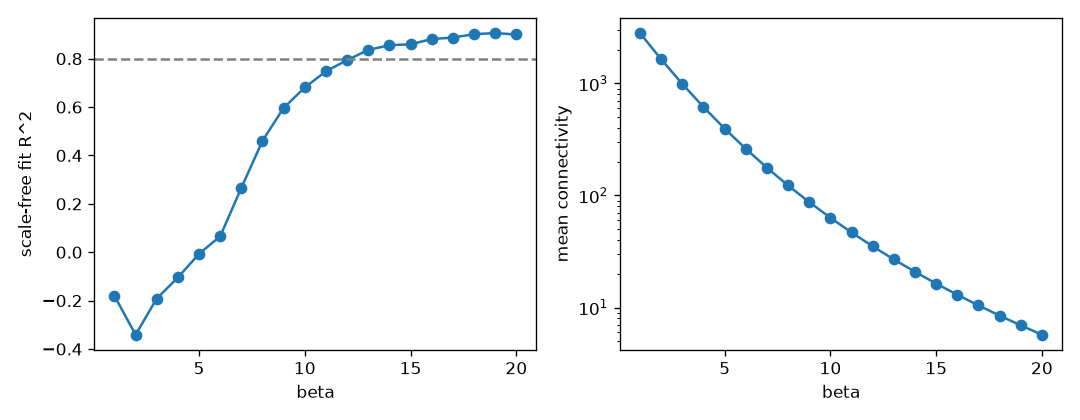

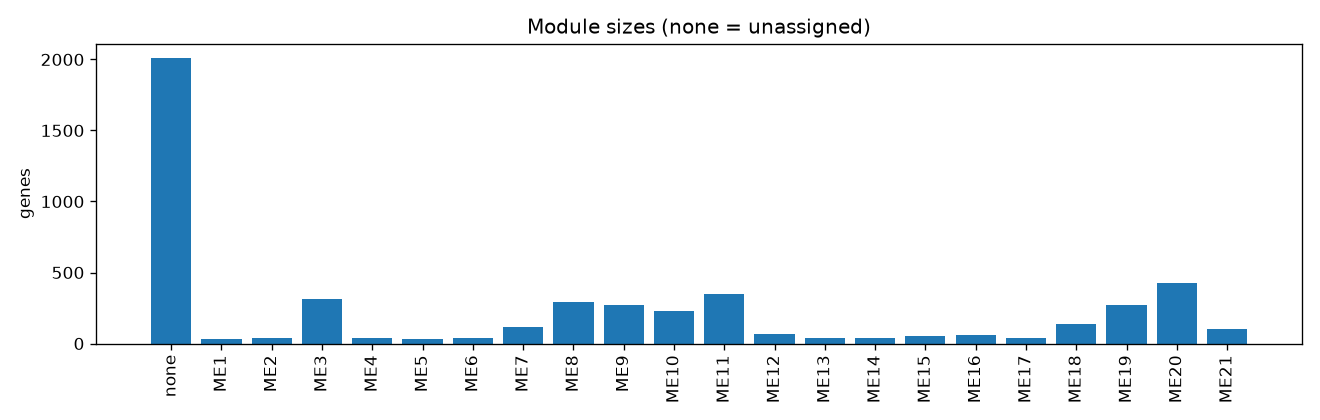

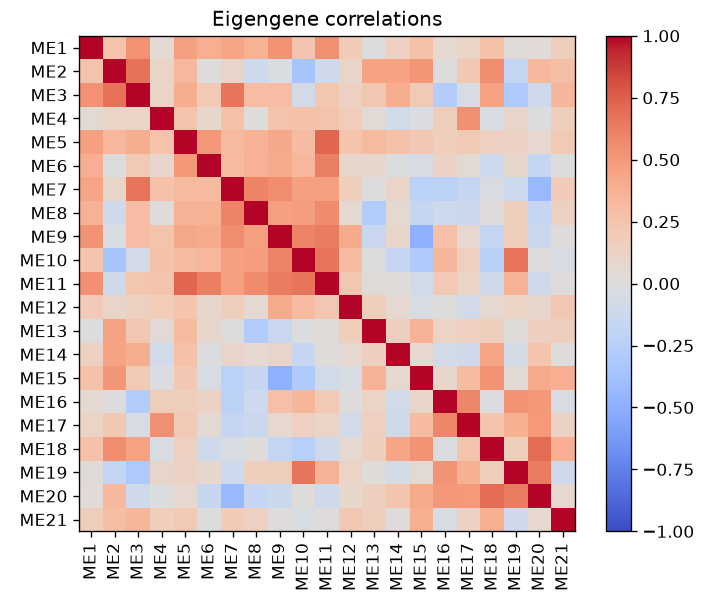

In [5]:
from IPython.display import Image, display
for f in ['results/step03_softthreshold.png','results/step03_module_sizes.png','results/step03_eigengene_cor.png']: display(Image(f))

**Findings.**
- ComBat brought the later/earlier batch spread ratio from 1.83 to 1.02. Eigengene correlation with batch is 0.00.
- 21 modules of 31 to 424 genes; 2,011 of 5,000 genes unassigned. Scale-free fit at beta 12 is 0.79, a proper network this time (the plain scaling run gave 0.55 and 9 coarse modules).
- Several modules are recognisable blood cell-type programmes from their hub genes: ME12 (NKG7, cytotoxic NK/T cells), ME17 (CD19, B cells), ME16 (LEF1, naive T cells), ME4 (IGLC1, immunoglobulin/plasma cells), ME14 (HERC5, interferon response), ME7 (GP1BB, platelets), ME13 (RPS11, ribosomal). That is what a whole-blood or PBMC expression profile should decompose into, which supports the module assignment.
- Consequence: eigengenes for cell-type modules will partly track blood cell composition. A module that predicts response may do so through cell counts rather than gene regulation; step 9 must keep this in mind when interpreting selected modules.

## Step 4 — Pipelines, nested cross-validation, baselines

**Where is the train/test split?** Inside every fold. Per the step 1 decision there is no single hold-out set: with 89 samples an 18-sample test set gives an AUC interval about 0.47 wide, too wide to learn anything. Instead the data is split 5 ways, each fifth is the test set once while the other four fifths train, and the whole procedure is repeated 20 times with different splits. Every number reported is computed only on samples the model did not see. Scaling and the choice of regularisation strength happen inside the training part of each fold (a scikit-learn `Pipeline` with an inner cross-validation), so nothing about the test fifth leaks into training. This is "nested cross-validation".

**What we do.** Logistic regression (L2) on three feature sets: clinical only; the 21 WGCNA eigengenes; eigengenes plus clinical. Compared against a chance model that predicts the class prior. Metrics: ROC-AUC (primary), PR-AUC, F1 at 0.5. Spread across the 20 repeats shows how much the score depends on which samples land in which fold; a bootstrap over samples gives a confidence interval for the main model.

**Why here.** This is the honest floor before any feature selection. If eigengenes plus clinical cannot beat chance under this scheme, no amount of selection downstream is justified.

**One caveat.** The eigengenes were computed on all 89 samples in step 3. That step never reads the label, so it is not label leakage, but it does mean the test fold's expression values contributed to defining the modules. This is standard practice for unsupervised preprocessing and matches the step 1 rules.

In [ ]:
%run step04_baselines.py

In [ ]:
from IPython.display import Image, display
display(Image('results/step04_cv_auc.png'))

**Findings.**

| model | ROC-AUC | PR-AUC | F1 | AUC range across repeats |
|---|---|---|---|---|
| chance | 0.49 | 0.60 | 0.76 | |
| clinical only | 0.51 | 0.62 | 0.71 | 0.45 to 0.58 |
| eigengenes only | 0.63 | 0.70 | 0.75 | 0.51 to 0.67 |
| eigengenes + clinical | 0.63 | 0.71 | 0.75 | 0.52 to 0.68 |

Bootstrap 95% CI for eigengenes + clinical: 0.42 to 0.66.

- Clinical variables alone predict nothing, as step 1 anticipated.
- Eigengenes carry a weak signal: AUC around 0.63, better than chance on every one of the 20 splits but never above 0.68. Adding clinical variables changes nothing.
- The bootstrap interval reaches below 0.5. With 89 samples we cannot yet rule out that this signal is noise. The permutation test (step 8) is the proper test of that.
- F1 is misleading here: the chance model gets 0.76 by calling everyone a Responder. Ignore F1 for this problem.

**Consequences.** There is something to select for, but it is small. Expect stability selection to return few modules, and treat any single-model AUC as provisional until the permutation test is done.